# NorthStar Urban Mobility — Full Analytical Solution
### Databases and Analytics Assignment | CP60056E

---
## Sections
1. Setup & Data Loading
2. SQL in R
3. R Analytics
4. Python Data Processing
5. MongoDB Development (CRUD + Aggregations)
6. Query Optimisation


---
## 1. Setup & Data Loading
### 1.1 Install packages

In [39]:
# Install all required packages
!pip install pymongo dnspython --quiet
!pip install pandas numpy matplotlib seaborn scipy scikit-learn --quiet

# Install R packages
import subprocess
result = subprocess.run(
    ['Rscript', '-e',
     'install.packages(c("sqldf","dplyr","ggplot2","corrplot","lubridate"), repos="https://cloud.r-project.org", quiet=TRUE)'],
    capture_output=True, text=True
)
print("R packages:", "OK" if result.returncode == 0 else result.stderr[:200])
print("All packages ready.")

R packages: OK
All packages ready.


### 1.2 Upload & Extract Dataset
Upload `northstar_dataset.zip` when prompted.

In [40]:
import os, zipfile
from google.colab import files

# Upload the zip file
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]
print(f"Uploaded: {zip_name}")

# Extract
EXTRACT_DIR = '/content/northstar_data'
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(EXTRACT_DIR)

# Find the folder containing CSVs by walking all subdirectories
DATA_DIR = None
for root, dirs, fnames in os.walk(EXTRACT_DIR):
    csv_files = [f for f in fnames if f.endswith('.csv')]
    if len(csv_files) >= 5:          # found the right folder
        DATA_DIR = root
        break

if DATA_DIR is None:
    raise FileNotFoundError("Could not find CSVs. Check your zip file structure.")

print(f"Data directory: {DATA_DIR}")
print("Files found:", sorted(os.listdir(DATA_DIR)))

Saving northstar_dataset.zip to northstar_dataset.zip
Uploaded: northstar_dataset.zip
Data directory: /content/northstar_data/northstar_dataset
Files found: ['README.txt', 'app_events.csv', 'complaints.csv', 'customers.csv', 'data_dictionary.csv', 'deliveries.csv', 'drivers.csv', 'hubs.csv', 'incidents.csv', 'orders.csv', 'vehicles.csv']


### 1.3 Load All CSVs

In [41]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

hubs       = pd.read_csv(f'{DATA_DIR}/hubs.csv')
customers  = pd.read_csv(f'{DATA_DIR}/customers.csv')
drivers    = pd.read_csv(f'{DATA_DIR}/drivers.csv')
vehicles   = pd.read_csv(f'{DATA_DIR}/vehicles.csv')
orders     = pd.read_csv(f'{DATA_DIR}/orders.csv')
deliveries = pd.read_csv(f'{DATA_DIR}/deliveries.csv')
incidents  = pd.read_csv(f'{DATA_DIR}/incidents.csv')
complaints = pd.read_csv(f'{DATA_DIR}/complaints.csv')
app_events = pd.read_csv(f'{DATA_DIR}/app_events.csv')

for name, df in [('hubs',hubs),('customers',customers),('drivers',drivers),
                 ('vehicles',vehicles),('orders',orders),('deliveries',deliveries),
                 ('incidents',incidents),('complaints',complaints),('app_events',app_events)]:
    print(f"{name:12s} -> {df.shape[0]:5d} rows x {df.shape[1]:2d} cols  |  nulls: {df.isnull().sum().sum()}")

hubs         ->     8 rows x  5 cols  |  nulls: 0
customers    ->   650 rows x  9 cols  |  nulls: 33
drivers      ->   170 rows x  8 cols  |  nulls: 7
vehicles     ->   120 rows x  8 cols  |  nulls: 4
orders       ->  1250 rows x 11 cols  |  nulls: 25
deliveries   ->   950 rows x 13 cols  |  nulls: 33
incidents    ->   280 rows x  7 cols  |  nulls: 17
complaints   ->   320 rows x 10 cols  |  nulls: 16
app_events   ->   640 rows x 10 cols  |  nulls: 144


### 1.4 Clean & Prepare Data

In [42]:
# ── Parse datetime columns ───────────────────────────────────────────────────
orders['order_created_at']          = pd.to_datetime(orders['order_created_at'],          errors='coerce')
deliveries['dispatch_time']         = pd.to_datetime(deliveries['dispatch_time'],          errors='coerce')
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'], errors='coerce')
complaints['created_at']            = pd.to_datetime(complaints['created_at'],             errors='coerce')
incidents['reported_at']            = pd.to_datetime(incidents['reported_at'],             errors='coerce')
app_events['event_timestamp']       = pd.to_datetime(app_events['event_timestamp'],        errors='coerce')

# ── Standardise zone text (mixed case in app_events) ─────────────────────────
app_events['zone_context'] = app_events['zone_context'].str.strip().str.title()

# ── Delivery duration ────────────────────────────────────────────────────────
deliveries['duration_hrs'] = (
    (deliveries['delivery_completed_at'] - deliveries['dispatch_time'])
    .dt.total_seconds() / 3600
).abs()

# ── Master joined table: orders + deliveries + customer + hub ────────────────
od = orders.merge(deliveries, on='order_id', how='left')
od = od.merge(customers[['customer_id','home_zone','customer_type','loyalty_score']], on='customer_id', how='left')
od = od.merge(hubs[['hub_id','hub_name','zone','capacity_score']], on='hub_id', how='left')

print(f"Master table shape: {od.shape}")
print("Delivery status counts:")
print(deliveries['delivery_status'].value_counts())

Master table shape: (1250, 30)
Delivery status counts:
delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64


---
## 2. SQL in R
Using `rpy2` to run R inside Python, and `sqldf` in R to query data frames with SQL.

In [43]:
%load_ext rpy2.ipython

In [44]:
%%R
library(sqldf)
library(dplyr)
library(ggplot2)
library(corrplot)
cat("R libraries loaded\n")

R libraries loaded


Loading required package: gsubfn
Loading required package: proto
Loading required package: RSQLite

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

corrplot 0.95 loaded
In addition: Warning message:
no DISPLAY variable so Tk is not available 


In [45]:
# Transfer all DataFrames to R
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
pandas2ri.activate()

ro.globalenv['orders_r']     = pandas2ri.py2rpy(orders)
ro.globalenv['deliveries_r'] = pandas2ri.py2rpy(deliveries)
ro.globalenv['customers_r']  = pandas2ri.py2rpy(customers)
ro.globalenv['drivers_r']    = pandas2ri.py2rpy(drivers)
ro.globalenv['vehicles_r']   = pandas2ri.py2rpy(vehicles)
ro.globalenv['hubs_r']       = pandas2ri.py2rpy(hubs)
ro.globalenv['incidents_r']  = pandas2ri.py2rpy(incidents)
ro.globalenv['complaints_r'] = pandas2ri.py2rpy(complaints)
ro.globalenv['app_events_r'] = pandas2ri.py2rpy(app_events)
print("All DataFrames transferred to R.")

All DataFrames transferred to R.


In [46]:
%%R
# SQL Q1 - Delivery failure rate and avg rating by hub zone
q1 <- sqldf("
  SELECT
      h.zone,
      COUNT(d.delivery_id)                                                     AS total_deliveries,
      SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)           AS failed,
      ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
            / COUNT(d.delivery_id), 2)                                         AS failure_rate_pct,
      ROUND(AVG(d.manual_route_override_count), 2)                            AS avg_overrides,
      ROUND(AVG(d.customer_rating_post_delivery), 2)                          AS avg_rating
  FROM deliveries_r d
  JOIN hubs_r h ON d.hub_id = h.hub_id
  GROUP BY h.zone
  ORDER BY failure_rate_pct DESC
")
cat("=== SQL Q1: Delivery Failure Rate by Hub Zone ===\n")
print(q1)

=== SQL Q1: Delivery Failure Rate by Hub Zone ===
       zone total_deliveries failed failure_rate_pct avg_overrides avg_rating
1   Central              243     49            20.16          1.03       3.78
2   Airport              104     15            14.42          0.91       3.88
3      West              127     16            12.60          0.87       3.92
4     North              136     17            12.50          1.03       3.84
5 Riverside              115     14            12.17          1.05       3.88
6     South              106     10             9.43          0.92       3.95
7      East              119     11             9.24          0.89       3.90


In [47]:
%%R
# SQL Q2 - Driver performance: failures, overrides, incidents
q2 <- sqldf("
  SELECT
      dr.driver_id,
      dr.employment_type,
      ROUND(dr.training_score, 1)                                              AS training_score,
      ROUND(dr.driver_rating, 2)                                               AS driver_rating,
      COUNT(d.delivery_id)                                                     AS total_deliveries,
      SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)           AS failures,
      ROUND(AVG(d.manual_route_override_count), 2)                            AS avg_overrides,
      ROUND(AVG(d.customer_rating_post_delivery), 2)                          AS avg_cust_rating,
      COUNT(i.incident_id)                                                     AS incidents
  FROM deliveries_r d
  LEFT JOIN drivers_r   dr ON d.driver_id   = dr.driver_id
  LEFT JOIN incidents_r i  ON d.delivery_id = i.delivery_id
  GROUP BY dr.driver_id, dr.employment_type, dr.training_score, dr.driver_rating
  HAVING total_deliveries >= 3
  ORDER BY failures DESC
  LIMIT 15
")
cat("=== SQL Q2: Driver Performance (Top 15 by Failures) ===\n")
print(q2)

=== SQL Q2: Driver Performance (Top 15 by Failures) ===
   driver_id employment_type training_score driver_rating total_deliveries
1       D024        PartTime           71.4          3.35                8
2       D104        FullTime           87.7          3.45                7
3       D133        Contract           88.2          3.99               12
4       D004        PartTime           88.9          4.75                9
5       D010        FullTime           70.0          3.95                7
6       D023        FullTime           79.1          4.16                7
7       D055        FullTime           90.5          5.00               10
8       D082        PartTime           74.1          4.63                7
9       D083        FullTime           80.8          4.16                9
10      D092        FullTime           88.2          4.24                5
11      D108        FullTime           70.6          4.33               11
12      D131        FullTime           86.7 

In [48]:
%%R
# SQL Q3 - Complaint rate and avg compensation by service type
q3 <- sqldf("
  SELECT
      o.service_type,
      COUNT(DISTINCT o.order_id)                                               AS total_orders,
      ROUND(AVG(o.order_value), 2)                                             AS avg_order_value,
      COUNT(c.complaint_id)                                                    AS total_complaints,
      ROUND(100.0 * COUNT(c.complaint_id) / COUNT(DISTINCT o.order_id), 2)    AS complaint_rate_pct,
      ROUND(AVG(c.compensation_amount), 2)                                     AS avg_compensation
  FROM orders_r o
  LEFT JOIN complaints_r c ON o.order_id = c.order_id
  GROUP BY o.service_type
  ORDER BY complaint_rate_pct DESC
")
cat("=== SQL Q3: Complaint Rate by Service Type ===\n")
print(q3)

=== SQL Q3: Complaint Rate by Service Type ===
  service_type total_orders avg_order_value total_complaints complaint_rate_pct
1       Retail          297           90.04               83              27.95
2      Medical          139           86.66               37              26.62
3       Parcel          308           88.57               77              25.00
4    Passenger          341           95.36               84              24.63
5     Business          165           92.96               39              23.64
  avg_compensation
1            19.05
2            20.56
3            20.61
4            20.72
5            20.79


In [49]:
%%R
# SQL Q4 - Vehicle maintenance vs incident count
q4 <- sqldf("
  SELECT
      v.maintenance_status,
      v.vehicle_type,
      COUNT(DISTINCT v.vehicle_id)         AS vehicles,
      ROUND(AVG(v.battery_health_pct), 2)  AS avg_battery_pct,
      ROUND(AVG(v.odometer_km), 0)         AS avg_odometer_km,
      COUNT(i.incident_id)                 AS incident_count,
      ROUND(AVG(i.resolved_hours), 2)      AS avg_resolve_hrs
  FROM vehicles_r v
  LEFT JOIN deliveries_r d  ON v.vehicle_id  = d.vehicle_id
  LEFT JOIN incidents_r  i  ON d.delivery_id = i.delivery_id
  GROUP BY v.maintenance_status, v.vehicle_type
  ORDER BY incident_count DESC
")
cat("=== SQL Q4: Vehicle Health vs Incidents ===\n")
print(q4)

=== SQL Q4: Vehicle Health vs Incidents ===
   maintenance_status vehicle_type vehicles avg_battery_pct avg_odometer_km
1              Active           EV       29           83.07          119113
2              Active     CargoVan       14           74.27          102825
3              Active       Hybrid       14           73.52          119188
4            InRepair       Diesel        7           75.11           96958
5            InRepair       Hybrid        9           82.89          129709
6           Scheduled           EV        6           82.94          134451
7              Active       Diesel       10           66.45           79271
8            InRepair     CargoVan       12           69.37          103780
9            InRepair           EV        8           77.80          147405
10          Scheduled       Hybrid        5           80.51          117494
11          Scheduled     CargoVan        4           69.00          140454
12          Scheduled       Diesel        2 

In [50]:
%%R
# SQL Q5 - Open high-severity complaints (operational risk list)
q5 <- sqldf("
  SELECT
      c.complaint_id,
      c.customer_id,
      c.complaint_type,
      c.severity,
      c.channel,
      c.resolution_days,
      ROUND(c.compensation_amount, 2)  AS compensation,
      o.service_type,
      ROUND(o.order_value, 2)          AS order_value
  FROM complaints_r c
  JOIN orders_r o ON c.order_id = o.order_id
  WHERE c.status = 'Open' AND c.severity = 'High'
  ORDER BY c.compensation_amount DESC
  LIMIT 15
")
cat("=== SQL Q5: Open High-Severity Complaints ===\n")
print(q5)

=== SQL Q5: Open High-Severity Complaints ===
   complaint_id customer_id  complaint_type severity channel resolution_days
1        CP0283       C0252 DriverBehaviour     High   Email              11
2        CP0261       C0566        AppIssue     High   Email              18
3        CP0161       C0107         Billing     High   Email               9
4        CP0294       C0339        AppIssue     High   Phone              19
5        CP0266       C0544          Damage     High     App              15
6        CP0133       C0480           Delay     High     App              15
7        CP0147       C0383 DriverBehaviour     High   Phone              15
8        CP0195       C0110           Delay     High   Phone               8
9        CP0131       C0583           Delay     High   Email              14
10       CP0003       C0469           Delay     High Chatbot              16
11       CP0001       C0464        AppIssue     High     App              11
12       CP0174       C0116 Dr

In [51]:
%%R
# SQL Q6 - Cost efficiency: cost per km by hub
q6 <- sqldf("
  SELECT
      h.hub_name,
      h.zone,
      h.capacity_score,
      COUNT(d.delivery_id)                                                     AS deliveries,
      ROUND(SUM(d.fuel_or_charge_cost), 2)                                    AS total_cost,
      ROUND(SUM(d.route_distance_km), 1)                                      AS total_km,
      ROUND(SUM(d.fuel_or_charge_cost) / NULLIF(SUM(d.route_distance_km),0), 3) AS cost_per_km,
      ROUND(AVG(d.customer_rating_post_delivery), 2)                          AS avg_rating
  FROM deliveries_r d
  JOIN hubs_r h ON d.hub_id = h.hub_id
  GROUP BY h.hub_id, h.hub_name, h.zone, h.capacity_score
  ORDER BY cost_per_km DESC
")
cat("=== SQL Q6: Cost Per KM by Hub ===\n")
print(q6)

=== SQL Q6: Cost Per KM by Hub ===
        hub_name      zone capacity_score deliveries total_cost total_km
1      West Gate      West             69        127    1672.21   1699.8
2   Central Core   Central             88        115    1573.89   1647.0
3 North Exchange     North             82        136    1734.79   1855.5
4    Airport Hub   Airport             71        104    1385.20   1498.9
5  Midtown Relay   Central             63        128    1498.65   1640.4
6  Riverside Hub Riverside             66        115    1486.04   1643.0
7     South Link     South             78        106    1331.89   1501.9
8      East Dock      East             74        119    1516.56   1727.3
  cost_per_km avg_rating
1       0.984       3.92
2       0.956       3.67
3       0.935       3.84
4       0.924       3.88
5       0.914       3.88
6       0.904       3.88
7       0.887       3.95
8       0.878       3.90


---
## 3. R Analytics — Statistical Analysis & Visualisation

In [52]:
%%R
# Merge tables inside R for analysis
od_r <- merge(orders_r, deliveries_r, by='order_id', all.x=TRUE)
od_r <- merge(od_r, hubs_r[, c('hub_id','zone','capacity_score')], by='hub_id', all.x=TRUE)
od_r <- merge(od_r, customers_r[, c('customer_id','customer_type','loyalty_score')], by='customer_id', all.x=TRUE)
cat(sprintf("Merged R table: %d rows x %d cols\n", nrow(od_r), ncol(od_r)))

Merged R table: 1250 rows x 28 cols


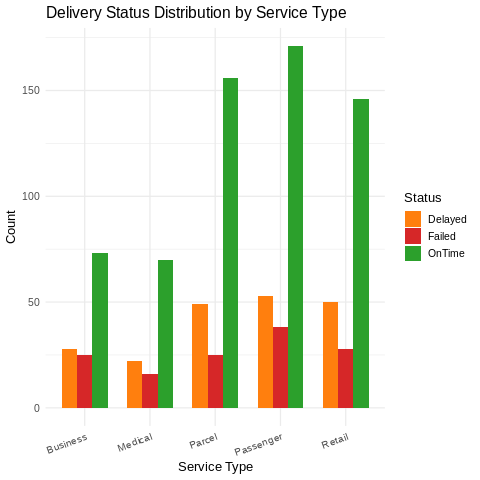

In [53]:
%%R
# R CHART 1 - Delivery status by service type
options(repr.plot.width=10, repr.plot.height=5)
tbl1 <- od_r[!is.na(od_r$delivery_status) & !is.na(od_r$service_type), ]
tbl1 <- aggregate(order_id ~ service_type + delivery_status, data=tbl1, FUN=length)
names(tbl1)[3] <- 'n'

ggplot(tbl1, aes(x=service_type, y=n, fill=delivery_status)) +
    geom_col(position='dodge', width=0.7) +
    scale_fill_manual(values=c('Failed'='#d62728','OnTime'='#2ca02c','Delayed'='#ff7f0e')) +
    labs(title='Delivery Status Distribution by Service Type',
         x='Service Type', y='Count', fill='Status') +
    theme_minimal(base_size=13) +
    theme(axis.text.x=element_text(angle=20, hjust=1))

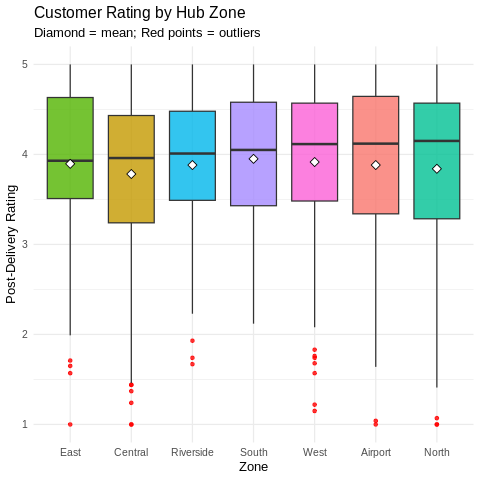

In [54]:
%%R
# R CHART 2 - Customer rating by zone (boxplot)
options(repr.plot.width=10, repr.plot.height=5)
box_data <- od_r[!is.na(od_r$customer_rating_post_delivery) & !is.na(od_r$zone), ]

ggplot(box_data, aes(x=reorder(zone, customer_rating_post_delivery, FUN=median),
                     y=customer_rating_post_delivery, fill=zone)) +
    geom_boxplot(alpha=0.8, outlier.colour='red', outlier.size=1.5) +
    stat_summary(fun=mean, geom='point', shape=23, size=3, fill='white') +
    labs(title='Customer Rating by Hub Zone',
         subtitle='Diamond = mean; Red points = outliers',
         x='Zone', y='Post-Delivery Rating') +
    theme_minimal(base_size=13) +
    theme(legend.position='none')

`geom_smooth()` using formula = 'y ~ x'


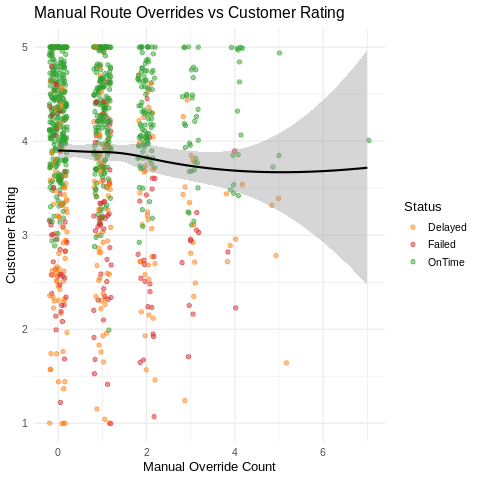

In [55]:
%%R
# R CHART 3 - Manual overrides vs customer rating (scatter + smooth)
options(repr.plot.width=10, repr.plot.height=5)
sc_data <- od_r[!is.na(od_r$manual_route_override_count) &
                !is.na(od_r$customer_rating_post_delivery), ]

ggplot(sc_data, aes(x=manual_route_override_count,
                    y=customer_rating_post_delivery,
                    colour=delivery_status)) +
    geom_jitter(alpha=0.5, width=0.2, size=1.8) +
    geom_smooth(aes(group=1), method='loess', colour='black', se=TRUE, linewidth=1) +
    scale_colour_manual(values=c('Failed'='#d62728','OnTime'='#2ca02c','Delayed'='#ff7f0e')) +
    labs(title='Manual Route Overrides vs Customer Rating',
         x='Manual Override Count', y='Customer Rating', colour='Status') +
    theme_minimal(base_size=13)

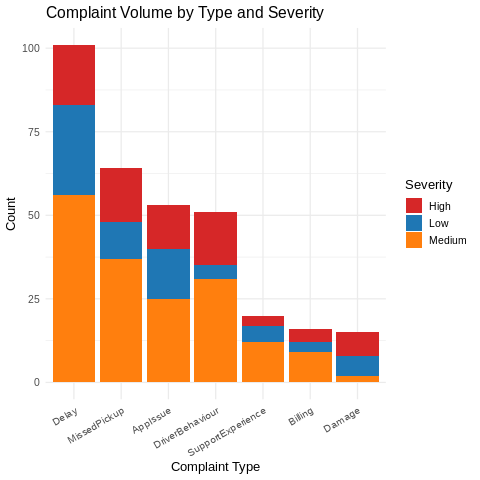

In [56]:
%%R
# R CHART 4 - Complaint severity stacked bar
options(repr.plot.width=10, repr.plot.height=5)
comp_tbl <- aggregate(complaint_id ~ complaint_type + severity, data=complaints_r, FUN=length)
names(comp_tbl)[3] <- 'n'
comp_tbl$complaint_type <- reorder(comp_tbl$complaint_type, -comp_tbl$n)

ggplot(comp_tbl, aes(x=complaint_type, y=n, fill=severity)) +
    geom_col(position='stack') +
    scale_fill_manual(values=c('High'='#d62728','Medium'='#ff7f0e','Low'='#1f77b4')) +
    labs(title='Complaint Volume by Type and Severity',
         x='Complaint Type', y='Count', fill='Severity') +
    theme_minimal(base_size=13) +
    theme(axis.text.x=element_text(angle=30, hjust=1))

In [57]:
%%R
# R STAT - ANOVA: Driver training score vs delivery failure rate
driver_perf <- merge(deliveries_r, drivers_r, by='driver_id', all.x=TRUE)
driver_perf$failed <- ifelse(driver_perf$delivery_status == 'Failed', 1, 0)
qs <- quantile(driver_perf$training_score, na.rm=TRUE)
driver_perf$training_band <- cut(driver_perf$training_score,
                                  breaks=qs, include.lowest=TRUE,
                                  labels=c('Q1 Low','Q2','Q3','Q4 High'))

aov_res <- aov(failed ~ training_band, data=driver_perf)
cat("=== ANOVA: Training Score vs Failure Rate ===\n")
print(summary(aov_res))

band_means <- aggregate(failed ~ training_band, data=driver_perf, FUN=mean)
band_means$failure_pct <- round(band_means$failed * 100, 2)
cat("\nFailure rate by training band:\n")
print(band_means[, c('training_band','failure_pct')])

=== ANOVA: Training Score vs Failure Rate ===
               Df Sum Sq Mean Sq F value Pr(>F)  
training_band   3   0.94  0.3139   2.607 0.0505 .
Residuals     906 109.05  0.1204                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
40 observations deleted due to missingness

Failure rate by training band:
  training_band failure_pct
1        Q1 Low        8.77
2            Q2       17.11
3            Q3       14.35
4       Q4 High       16.07


=== Pearson Correlation Matrix ===
                              manual_route_override_count
manual_route_override_count                         1.000
customer_rating_post_delivery                      -0.060
fuel_or_charge_cost                                 0.099
route_distance_km                                   0.199
                              customer_rating_post_delivery fuel_or_charge_cost
manual_route_override_count                          -0.060               0.099
customer_rating_post_delivery                         1.000              -0.059
fuel_or_charge_cost                                  -0.059               1.000
route_distance_km                                     0.029               0.527
                              route_distance_km
manual_route_override_count               0.199
customer_rating_post_delivery             0.029
fuel_or_charge_cost                       0.527
route_distance_km                         1.000


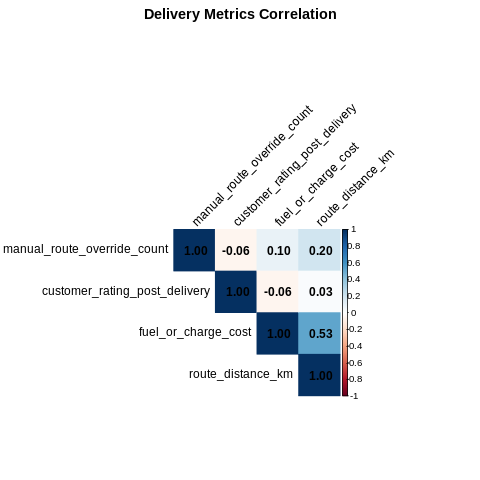

In [58]:
%%R
# R CHART 5 - Correlation matrix of delivery numeric metrics
options(repr.plot.width=7, repr.plot.height=6)
num_data <- na.omit(deliveries_r[, c('manual_route_override_count',
                                      'customer_rating_post_delivery',
                                      'fuel_or_charge_cost',
                                      'route_distance_km')])
cor_mat <- cor(num_data)
cat("=== Pearson Correlation Matrix ===\n")
print(round(cor_mat, 3))
corrplot(cor_mat, method='color', type='upper', addCoef.col='black',
         tl.col='black', tl.srt=45, title='Delivery Metrics Correlation',
         mar=c(0,0,2,0))

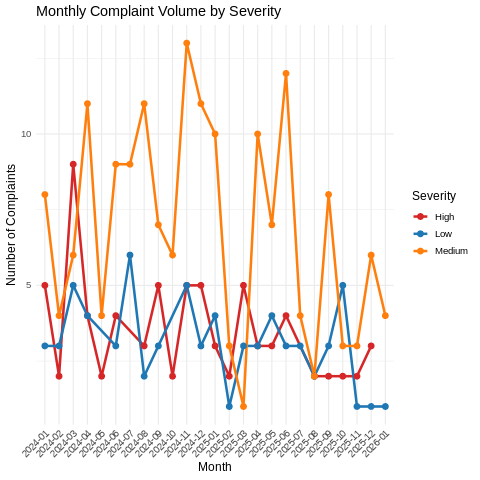

In [59]:
%%R
# R CHART 6 - Monthly complaint trend
options(repr.plot.width=12, repr.plot.height=5)
complaints_r$month_yr <- format(as.POSIXct(complaints_r$created_at), '%Y-%m')
monthly <- aggregate(complaint_id ~ month_yr + severity, data=complaints_r, FUN=length)
names(monthly)[3] <- 'n'
monthly <- monthly[order(monthly$month_yr), ]

ggplot(monthly, aes(x=month_yr, y=n, colour=severity, group=severity)) +
    geom_line(linewidth=1.2) +
    geom_point(size=2.5) +
    scale_colour_manual(values=c('High'='#d62728','Medium'='#ff7f0e','Low'='#1f77b4')) +
    labs(title='Monthly Complaint Volume by Severity',
         x='Month', y='Number of Complaints', colour='Severity') +
    theme_minimal(base_size=12) +
    theme(axis.text.x=element_text(angle=45, hjust=1))

---
## 4. Python Data Processing — Pandas / NumPy / Visualisation

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110
print("Python analytics libraries ready.")

Python analytics libraries ready.


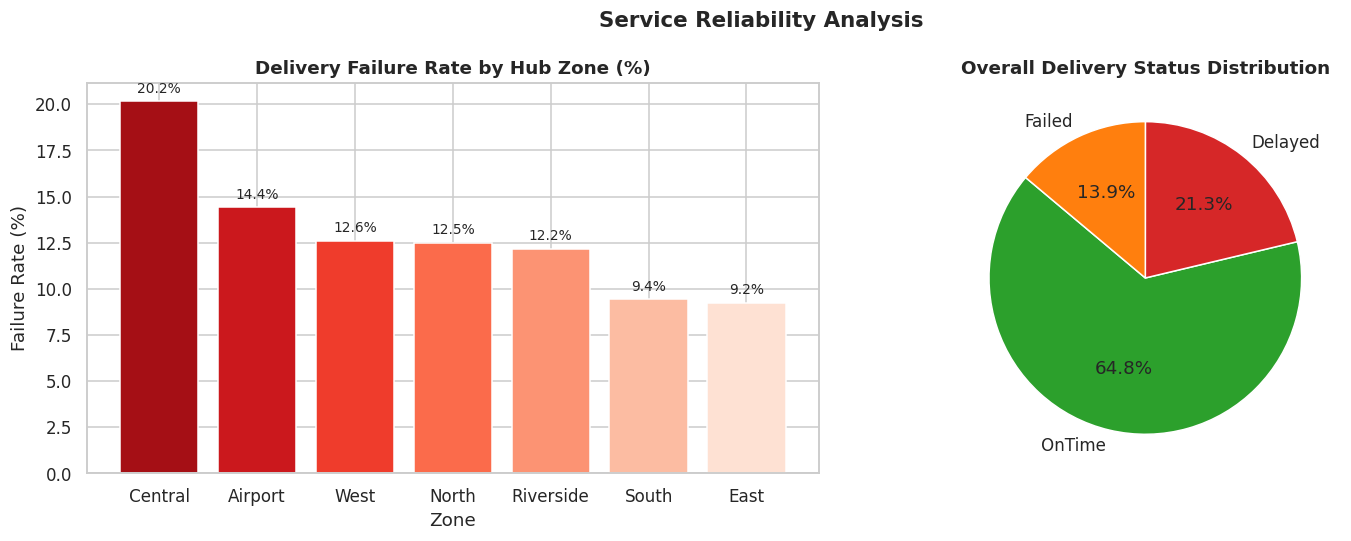

In [61]:
# PYTHON CHART 1 - Delivery failure rate by zone
zone_fail = (
    od.groupby('zone')['delivery_status']
    .value_counts(normalize=True).mul(100)
    .rename('pct').reset_index()
)
fail_only = zone_fail[zone_fail['delivery_status'] == 'Failed'].sort_values('pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('Reds_r', len(fail_only))
bars = axes[0].bar(fail_only['zone'], fail_only['pct'], color=colors, edgecolor='white')
axes[0].set_title('Delivery Failure Rate by Hub Zone (%)', fontweight='bold')
axes[0].set_ylabel('Failure Rate (%)')
axes[0].set_xlabel('Zone')
for bar, val in zip(bars, fail_only['pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Overall status pie
status_counts = deliveries['delivery_status'].value_counts()
axes[1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=['#2ca02c','#d62728','#ff7f0e'],
            startangle=140, wedgeprops={'edgecolor':'white'})
axes[1].set_title('Overall Delivery Status Distribution', fontweight='bold')

plt.suptitle('Service Reliability Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

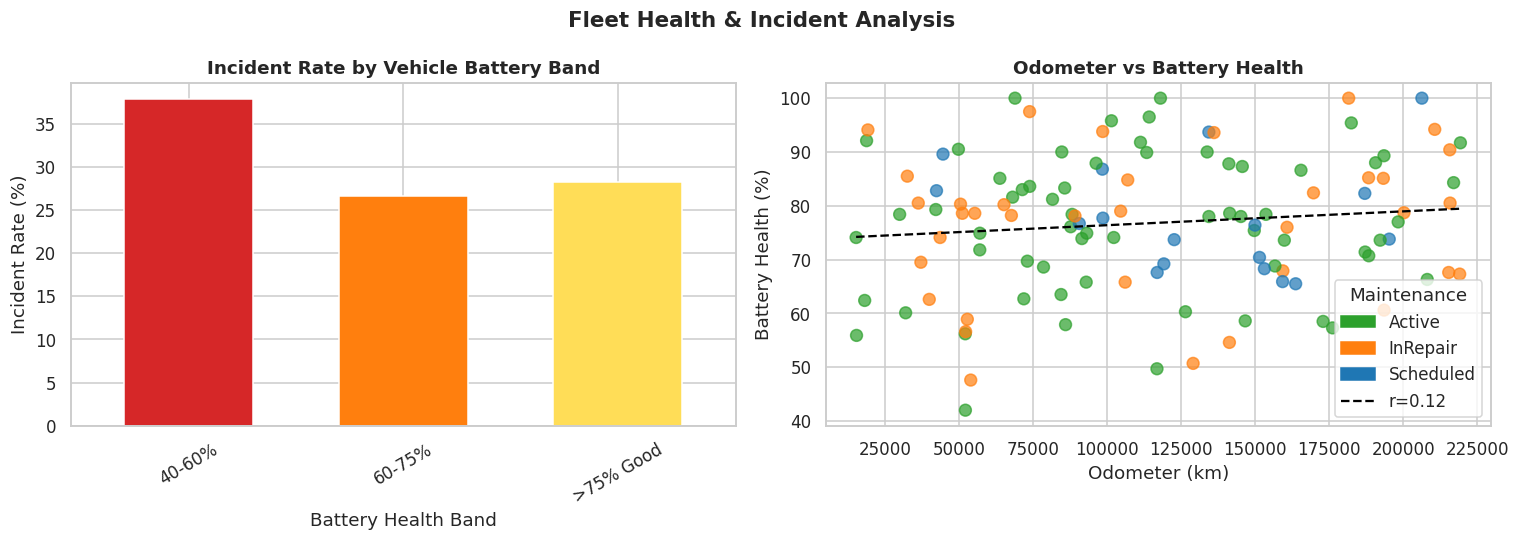

In [62]:
# PYTHON CHART 2 - Vehicle battery health vs incident rate
veh_del = deliveries.merge(
    vehicles[['vehicle_id','battery_health_pct','maintenance_status','odometer_km']],
    on='vehicle_id', how='left'
)
veh_inc = veh_del.merge(
    incidents[['delivery_id','incident_type','severity']],
    on='delivery_id', how='left'
)
veh_inc['has_incident'] = veh_inc['incident_type'].notna().astype(int)
veh_inc['battery_band'] = pd.cut(
    veh_inc['battery_health_pct'],
    bins=[0, 40, 60, 75, 100],
    labels=['<40% Critical','40-60%','60-75%','>75% Good']
)
battery_incident = veh_inc.groupby('battery_band', observed=True)['has_incident'].mean().mul(100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

battery_incident.plot(kind='bar', ax=axes[0],
                      color=['#d62728','#ff7f0e','#ffdd57','#2ca02c'],
                      edgecolor='white', width=0.6)
axes[0].set_title('Incident Rate by Vehicle Battery Band', fontweight='bold')
axes[0].set_ylabel('Incident Rate (%)')
axes[0].set_xlabel('Battery Health Band')
axes[0].tick_params(axis='x', rotation=30)

# Scatter: odometer vs battery
veh_clean = vehicles.dropna(subset=['battery_health_pct','odometer_km'])
maint_colors = veh_clean['maintenance_status'].map(
    {'Active':'#2ca02c','InRepair':'#ff7f0e','Scheduled':'#1f77b4'}
)
axes[1].scatter(veh_clean['odometer_km'], veh_clean['battery_health_pct'],
                c=maint_colors, alpha=0.7, s=60)
m, b, r, p, _ = stats.linregress(veh_clean['odometer_km'], veh_clean['battery_health_pct'])
x_range = np.linspace(veh_clean['odometer_km'].min(), veh_clean['odometer_km'].max(), 100)
axes[1].plot(x_range, m*x_range + b, 'k--', linewidth=1.5, label=f'r = {r:.2f}')
axes[1].set_title('Odometer vs Battery Health', fontweight='bold')
axes[1].set_xlabel('Odometer (km)')
axes[1].set_ylabel('Battery Health (%)')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='#2ca02c',label='Active'),
                         Patch(color='#ff7f0e',label='InRepair'),
                         Patch(color='#1f77b4',label='Scheduled')] +
               [plt.Line2D([0],[0],color='k',linestyle='--',label=f'r={r:.2f}')],
               title='Maintenance')

plt.suptitle('Fleet Health & Incident Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

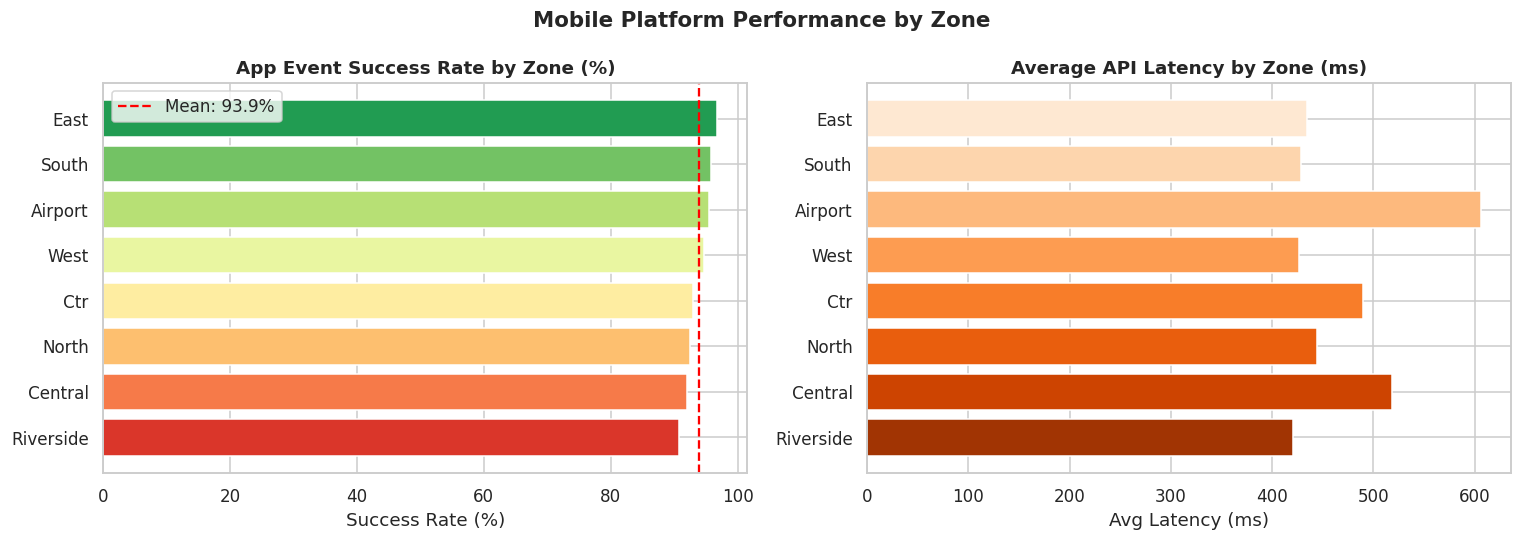

In [63]:
# PYTHON CHART 3 - App platform performance by zone
app_zone = app_events.groupby('zone_context').agg(
    total=('event_id','count'),
    success_rate=('success_flag','mean'),
    avg_latency=('api_latency_ms','mean')
).reset_index()
app_zone['success_rate'] = app_zone['success_rate'] * 100
app_zone = app_zone.sort_values('success_rate')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = sns.color_palette('RdYlGn', len(app_zone))
axes[0].barh(app_zone['zone_context'], app_zone['success_rate'], color=palette)
axes[0].axvline(app_zone['success_rate'].mean(), color='red', linestyle='--',
                label=f"Mean: {app_zone['success_rate'].mean():.1f}%")
axes[0].set_title('App Event Success Rate by Zone (%)', fontweight='bold')
axes[0].set_xlabel('Success Rate (%)')
axes[0].legend()

axes[1].barh(app_zone['zone_context'], app_zone['avg_latency'],
             color=sns.color_palette('Oranges_r', len(app_zone)))
axes[1].set_title('Average API Latency by Zone (ms)', fontweight='bold')
axes[1].set_xlabel('Avg Latency (ms)')

plt.suptitle('Mobile Platform Performance by Zone', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

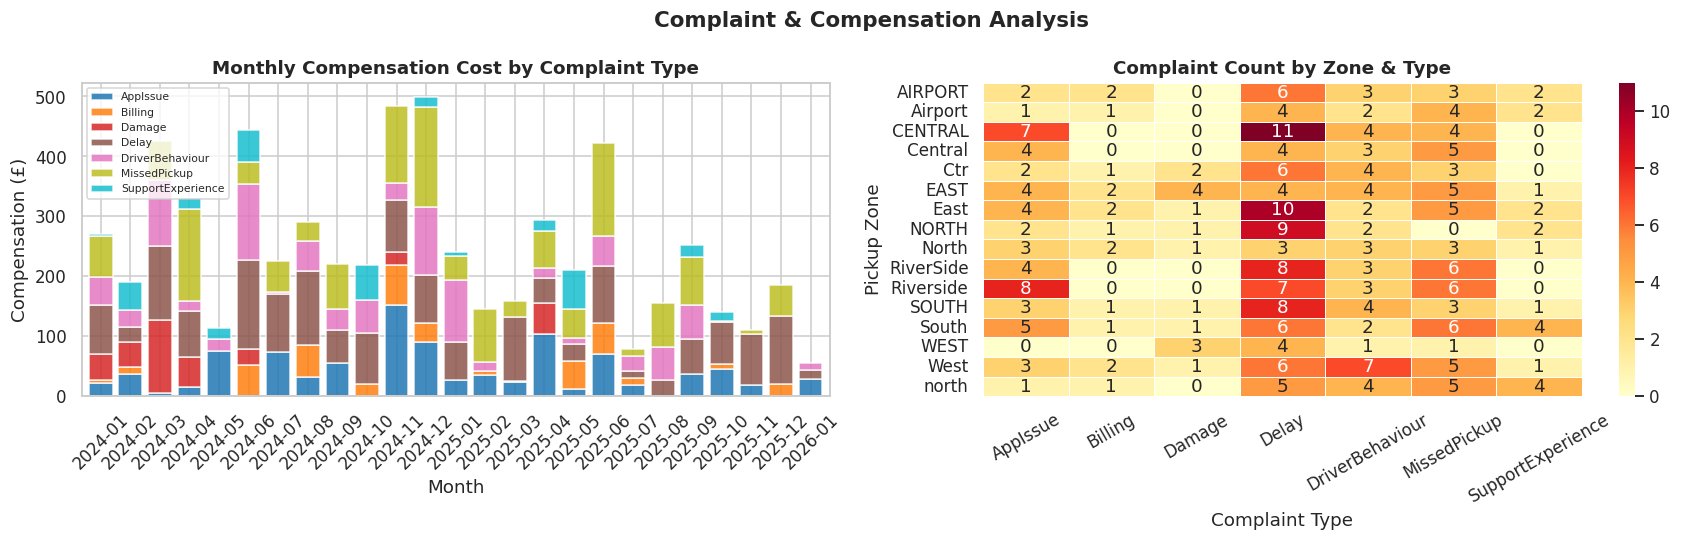

In [64]:
# PYTHON CHART 4 - Complaint compensation heatmap and monthly trend
complaints['month'] = complaints['created_at'].dt.to_period('M').astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly compensation stacked bar
comp_monthly = (
    complaints.groupby(['month','complaint_type'])['compensation_amount']
    .sum().unstack(fill_value=0)
)
comp_monthly.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10', alpha=0.85, width=0.8)
axes[0].set_title('Monthly Compensation Cost by Complaint Type', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Compensation (£)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=7, loc='upper left')

# Heatmap: zone vs complaint type
comp_zone = complaints.merge(orders[['order_id','pickup_zone']], on='order_id', how='left')
heatmap_data = comp_zone.groupby(['pickup_zone','complaint_type']).size().unstack(fill_value=0)
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.4, ax=axes[1])
axes[1].set_title('Complaint Count by Zone & Type', fontweight='bold')
axes[1].set_xlabel('Complaint Type')
axes[1].set_ylabel('Pickup Zone')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Complaint & Compensation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

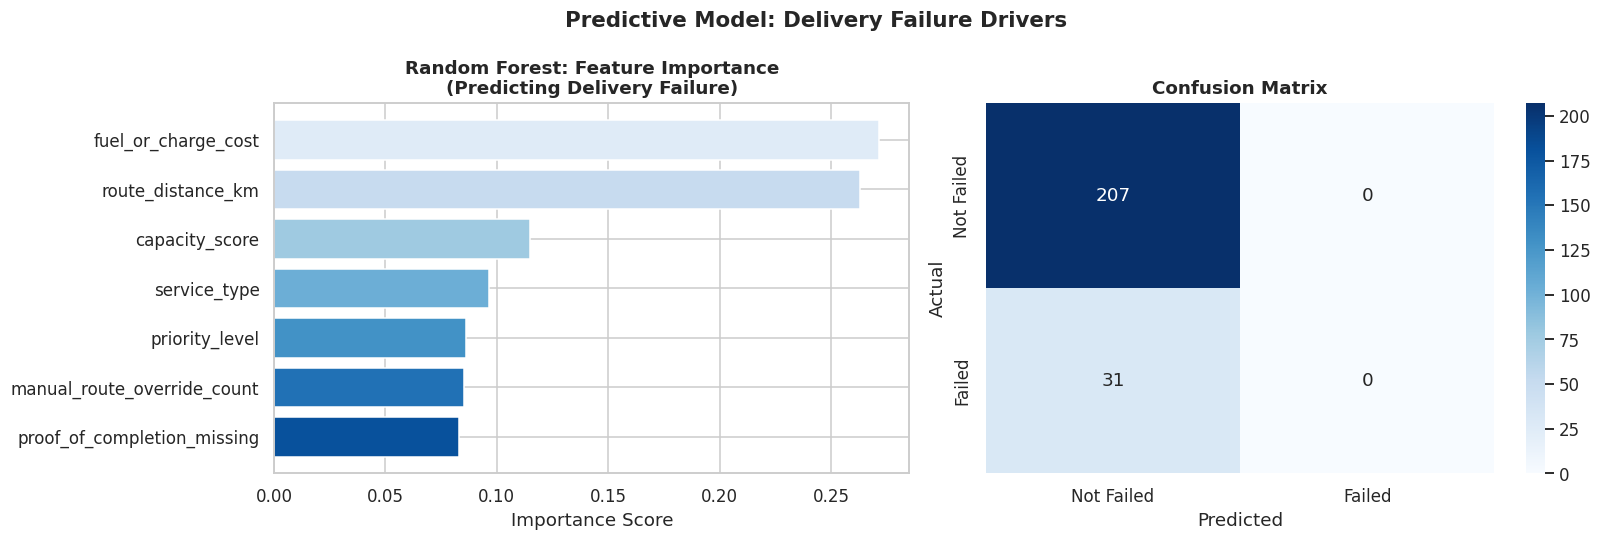


Classification Report:
              precision    recall  f1-score   support

  Not Failed       0.87      1.00      0.93       207
      Failed       0.00      0.00      0.00        31

    accuracy                           0.87       238
   macro avg       0.43      0.50      0.47       238
weighted avg       0.76      0.87      0.81       238



In [65]:
# PYTHON CHART 5 - Random Forest: feature importance for delivery failure
rf_data = od[['delivery_status','manual_route_override_count','route_distance_km',
              'fuel_or_charge_cost','proof_of_completion_missing',
              'capacity_score','service_type','priority_level']].dropna().copy()

rf_data['failed'] = (rf_data['delivery_status'] == 'Failed').astype(int)

le = LabelEncoder()
for col in ['service_type','priority_level']:
    rf_data[col] = le.fit_transform(rf_data[col].astype(str))

FEATURES = ['manual_route_override_count','route_distance_km','fuel_or_charge_cost',
            'proof_of_completion_missing','capacity_score','service_type','priority_level']

X = rf_data[FEATURES]
y = rf_data['failed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
rf = RandomForestClassifier(n_estimators=150, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

importance_df = (
    pd.DataFrame({'feature': FEATURES, 'importance': rf.feature_importances_})
    .sort_values('importance', ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(importance_df['feature'], importance_df['importance'],
             color=sns.color_palette('Blues_r', len(FEATURES)))
axes[0].set_title('Random Forest: Feature Importance\n(Predicting Delivery Failure)', fontweight='bold')
axes[0].set_xlabel('Importance Score')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Not Failed','Failed'],
            yticklabels=['Not Failed','Failed'])
axes[1].set_title('Confusion Matrix', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Predictive Model: Delivery Failure Drivers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Failed','Failed']))

In [66]:
# PYTHON - NumPy descriptive statistics summary
cols_for_stats = deliveries[['manual_route_override_count','route_distance_km',
                               'fuel_or_charge_cost','customer_rating_post_delivery',
                               'duration_hrs']].dropna()

summary = pd.DataFrame({
    'Mean':   np.mean(cols_for_stats),
    'Median': np.median(cols_for_stats),
    'StdDev': np.std(cols_for_stats),
    'Min':    np.min(cols_for_stats),
    'Max':    np.max(cols_for_stats),
    'IQR':    np.subtract(*np.percentile(cols_for_stats, [75, 25], axis=0))
}).round(3)

print("=== NumPy Descriptive Statistics: Delivery Metrics ===")
print(summary.to_string())

=== NumPy Descriptive Statistics: Delivery Metrics ===
                                Mean  Median  StdDev  Min     Max    IQR
manual_route_override_count    8.249     5.0   1.093  0.0  43.457   2.00
route_distance_km              8.249     5.0   7.448  0.0  43.457   7.61
fuel_or_charge_cost            8.249     5.0   4.296  0.0  43.457   5.65
customer_rating_post_delivery  8.249     5.0   0.896  0.0  43.457   1.20
duration_hrs                   8.249     5.0   8.537  0.0  43.457  11.74


---
## 5. MongoDB Development — PyMongo, CRUD & Aggregations

### NoSQL Design Rationale
Three collections are designed to reflect NorthStar's operational complexity:
- **`deliveries`** — embeds order context, driver/vehicle snapshots, incidents, app events
- **`customer_cases`** — embeds full complaint and order history per customer
- **`fleet_status`** — vehicle health with embedded incident records

**Replace the URI below with your MongoDB Atlas connection string.**


In [154]:
from pymongo import MongoClient, ASCENDING, DESCENDING
from urllib.parse import quote_plus

username = 'mashoodwork7_db_user'
password = 'Mash123#*'

uri = (
    f'mongodb+srv://{quote_plus(username)}:{quote_plus(password)}'
    f'@cluster0.jzv4qmj.mongodb.net/northstar_db'
    f'?retryWrites=true&w=majority&appName=Cluster0'
)

client = MongoClient(uri, serverSelectionTimeoutMS=15000, tlsAllowInvalidCertificates=True)
client.admin.command('ping')
db = client['northstar_db']
print("✅ Connected — database: northstar_db")

✅ Connected — database: northstar_db


In [155]:
from pymongo import MongoClient
from urllib.parse import quote_plus
import time

username = 'mashoodwork7_db_user'
password = 'Mash123#*'   # your password

uri = (
    f'mongodb+srv://{quote_plus(username)}:{quote_plus(password)}'
    f'@cluster0.jzv4qmj.mongodb.net/'
    f'?retryWrites=true&w=majority&appName=Cluster0&tlsAllowInvalidCertificates=true'
)

client = MongoClient(uri, serverSelectionTimeoutMS=15000)

try:
    client.admin.command('ping')
    print("✅ Connected to MongoDB Atlas!")
    db = client['northstar_db']
    print(f"✅ Database: northstar_db")
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("\n--- CHECKLIST ---")
    print("1. Go to Atlas → Security → Network Access")
    print("2. Click + Add IP Address → Allow Access from Anywhere (0.0.0.0/0)")
    print("3. Wait 2 minutes then run this cell again")

✅ Connected to MongoDB Atlas!
✅ Database: northstar_db


In [156]:
# Drop and recreate collections (idempotent)
for col_name in ['deliveries_col','customer_cases','fleet_status']:
    db[col_name].drop()
print("Collections dropped — ready for insert.")

Collections dropped — ready for insert.


In [157]:
# ── Pre-build lookup dictionaries ─────────────────────────────────────────────
order_map   = orders.set_index('order_id').to_dict('index')
driver_map  = drivers.set_index('driver_id').to_dict('index')
vehicle_map = vehicles.set_index('vehicle_id').to_dict('index')
hub_map     = hubs.set_index('hub_id').to_dict('index')

inc_by_del = (
    incidents.groupby('delivery_id')
    .apply(lambda g: g[['incident_type','severity','resolution_status','resolved_hours']].to_dict('records'))
    .to_dict()
)

app_by_ord = (
    app_events.dropna(subset=['order_id'])
    .groupby('order_id')
    .apply(lambda g: g[['event_id','event_type','device_type','api_latency_ms','success_flag']].to_dict('records'))
    .to_dict()
)

def safe_float(val):
    try:
        return float(val) if val is not None and not (isinstance(val, float) and np.isnan(val)) else None
    except: return None

def safe_int(val):
    try:
        return int(val) if val is not None and not (isinstance(val, float) and np.isnan(val)) else None
    except: return None

def safe_str(val):
    return str(val) if val is not None and str(val) not in ('nan','None','') else None

# ── BUILD COLLECTION 1: deliveries_col ───────────────────────────────────────
delivery_docs = []
for _, row in deliveries.iterrows():
    did  = str(row['delivery_id'])
    oid  = safe_str(row.get('order_id'))
    vid  = safe_str(row.get('vehicle_id'))
    drid = safe_str(row.get('driver_id'))
    hid  = safe_str(row.get('hub_id'))

    oi = order_map.get(row.get('order_id'), {})
    vi = vehicle_map.get(row.get('vehicle_id'), {})
    di = driver_map.get(row.get('driver_id'), {})
    hi = hub_map.get(row.get('hub_id'), {})

    doc = {
        '_id':                         did,
        'order_id':                    oid,
        'dispatch_time':               str(row.get('dispatch_time','')),
        'completed_at':                str(row.get('delivery_completed_at','')),
        'delivery_status':             safe_str(row.get('delivery_status')),
        'route_distance_km':           safe_float(row.get('route_distance_km')),
        'manual_route_override_count': safe_int(row.get('manual_route_override_count')),
        'proof_of_completion_missing': bool(row.get('proof_of_completion_missing', False)),
        'customer_rating':             safe_float(row.get('customer_rating_post_delivery')),
        'fuel_or_charge_cost':         safe_float(row.get('fuel_or_charge_cost')),
        'order': {
            'service_type':   safe_str(oi.get('service_type')),
            'order_value':    safe_float(oi.get('order_value')),
            'priority_level': safe_str(oi.get('priority_level')),
            'pickup_zone':    safe_str(oi.get('pickup_zone')),
            'dropoff_zone':   safe_str(oi.get('dropoff_zone')),
        },
        'hub': {
            'hub_id':         hid,
            'hub_name':       safe_str(hi.get('hub_name')),
            'zone':           safe_str(hi.get('zone')),
            'capacity_score': safe_int(hi.get('capacity_score')),
        },
        'driver': {
            'driver_id':       drid,
            'employment_type': safe_str(di.get('employment_type')),
            'training_score':  safe_float(di.get('training_score')),
            'driver_rating':   safe_float(di.get('driver_rating')),
        },
        'vehicle': {
            'vehicle_id':         vid,
            'vehicle_type':       safe_str(vi.get('vehicle_type')),
            'battery_health_pct': safe_float(vi.get('battery_health_pct')),
            'maintenance_status': safe_str(vi.get('maintenance_status')),
        },
        'incidents':  inc_by_del.get(row['delivery_id'], []),
        'app_events': app_by_ord.get(row.get('order_id'), []) if oid else [],
    }
    delivery_docs.append(doc)

result = db['deliveries_col'].insert_many(delivery_docs)
print(f"Inserted {len(result.inserted_ids)} documents into [deliveries_col]")

Inserted 950 documents into [deliveries_col]


In [158]:
# ── BUILD COLLECTION 2: customer_cases ───────────────────────────────────────
complaints_by_cust = (
    complaints.dropna(subset=['customer_id'])
    .groupby('customer_id')
    .apply(lambda g: g[['complaint_id','complaint_type','severity','channel',
                          'status','resolution_days','compensation_amount','created_at']]
           .assign(created_at=lambda x: x['created_at'].astype(str))
           .to_dict('records'))
    .to_dict()
)

orders_by_cust = (
    orders.groupby('customer_id')
    .apply(lambda g: g[['order_id','service_type','order_value',
                          'pickup_zone','dropoff_zone','priority_level']].to_dict('records'))
    .to_dict()
)

customer_docs = []
for _, row in customers.iterrows():
    cid   = str(row['customer_id'])
    comps = complaints_by_cust.get(row['customer_id'], [])
    ords  = orders_by_cust.get(row['customer_id'], [])
    doc = {
        '_id':              cid,
        'age':              safe_int(row.get('age')),
        'home_zone':        safe_str(row.get('home_zone')),
        'customer_type':    safe_str(row.get('customer_type')),
        'loyalty_score':    safe_float(row.get('loyalty_score')),
        'account_status':   safe_str(row.get('account_status')),
        'preferred_channel':safe_str(row.get('preferred_channel')),
        'orders':           ords,
        'complaints':       comps,
        'total_orders':     len(ords),
        'total_complaints': len(comps),
        'total_compensation': round(sum(safe_float(c.get('compensation_amount')) or 0 for c in comps), 2),
    }
    customer_docs.append(doc)

result = db['customer_cases'].insert_many(customer_docs)
print(f"Inserted {len(result.inserted_ids)} documents into [customer_cases]")

Inserted 650 documents into [customer_cases]


In [159]:
# ── BUILD COLLECTION 3: fleet_status ────────────────────────────────────────
del_veh = deliveries.set_index('delivery_id')['vehicle_id'].to_dict()
incidents['vehicle_id'] = incidents['delivery_id'].map(del_veh)

inc_by_veh = (
    incidents.dropna(subset=['vehicle_id'])
    .groupby('vehicle_id')
    .apply(lambda g: g[['incident_id','incident_type','severity',
                          'resolution_status','resolved_hours']].to_dict('records'))
    .to_dict()
)

del_by_veh = (
    deliveries.groupby('vehicle_id')
    .agg(total=('delivery_id','count'),
         failed=('delivery_status', lambda x: (x=='Failed').sum()),
         avg_override=('manual_route_override_count','mean'),
         total_km=('route_distance_km','sum'),
         total_cost=('fuel_or_charge_cost','sum'))
    .to_dict('index')
)

fleet_docs = []
for _, row in vehicles.iterrows():
    vid = str(row['vehicle_id'])
    ds  = del_by_veh.get(row['vehicle_id'], {})
    doc = {
        '_id':               vid,
        'vehicle_type':      safe_str(row.get('vehicle_type')),
        'assigned_zone':     safe_str(row.get('assigned_zone')),
        'commission_date':   str(row.get('commission_date','')),
        'battery_health_pct':safe_float(row.get('battery_health_pct')),
        'odometer_km':       safe_float(row.get('odometer_km')),
        'maintenance_status':safe_str(row.get('maintenance_status')),
        'telematics_version':safe_str(row.get('telematics_version')),
        'delivery_summary': {
            'total_deliveries':  safe_int(ds.get('total')),
            'failed_deliveries': safe_int(ds.get('failed')),
            'avg_override':      round(float(ds.get('avg_override') or 0), 2),
            'total_km':          round(float(ds.get('total_km') or 0), 1),
            'total_cost':        round(float(ds.get('total_cost') or 0), 2),
        },
        'incidents': inc_by_veh.get(row['vehicle_id'], []),
    }
    fleet_docs.append(doc)

result = db['fleet_status'].insert_many(fleet_docs)
print(f"Inserted {len(result.inserted_ids)} documents into [fleet_status]")

Inserted 120 documents into [fleet_status]


### 5.2 CRUD Operations

In [160]:
# CREATE - Insert a new test delivery document
new_doc = {
    '_id': 'DL_TEST_001',
    'order_id': 'O_TEST_001',
    'dispatch_time': '2025-06-01 08:00:00',
    'completed_at':  '2025-06-01 10:30:00',
    'delivery_status': 'OnTime',
    'route_distance_km': 12.5,
    'manual_route_override_count': 0,
    'proof_of_completion_missing': False,
    'customer_rating': 4.8,
    'fuel_or_charge_cost': 9.50,
    'order':   {'service_type':'LastMile','order_value':75.0,'priority_level':'High',
                 'pickup_zone':'North','dropoff_zone':'South'},
    'hub':     {'hub_id':'H01','hub_name':'North Exchange','zone':'North','capacity_score':82},
    'driver':  {'driver_id':'D001','employment_type':'FullTime','training_score':85.0,'driver_rating':4.5},
    'vehicle': {'vehicle_id':'V001','vehicle_type':'EV','battery_health_pct':88.0,'maintenance_status':'Active'},
    'incidents':  [],
    'app_events': []
}
ins = db['deliveries_col'].insert_one(new_doc)
print(f"CREATE - Inserted ID: {ins.inserted_id}")

CREATE - Inserted ID: DL_TEST_001


In [161]:
# READ - Find failed deliveries with >= 2 manual overrides
results = list(db['deliveries_col'].find(
    {'delivery_status': 'Failed', 'manual_route_override_count': {'$gte': 2}},
    {'_id':1, 'hub.zone':1, 'driver.training_score':1,
     'manual_route_override_count':1, 'customer_rating':1}
).limit(5))
print(f"READ - Found {db['deliveries_col'].count_documents({'delivery_status':'Failed','manual_route_override_count':{'$gte':2}})} failed deliveries with >= 2 overrides")
print("Sample (first 5):")
for r in results:
    print(" ", r)

READ - Found 35 failed deliveries with >= 2 overrides
Sample (first 5):
  {'_id': 'DL00012', 'manual_route_override_count': 3, 'customer_rating': None, 'hub': {'zone': 'Central'}, 'driver': {'training_score': 75.4}}
  {'_id': 'DL00026', 'manual_route_override_count': 2, 'customer_rating': 2.23, 'hub': {'zone': 'West'}, 'driver': {'training_score': 88.2}}
  {'_id': 'DL00038', 'manual_route_override_count': 2, 'customer_rating': 3.43, 'hub': {'zone': 'South'}, 'driver': {'training_score': 56.4}}
  {'_id': 'DL00041', 'manual_route_override_count': 3, 'customer_rating': 2.94, 'hub': {'zone': 'Central'}, 'driver': {'training_score': 62.0}}
  {'_id': 'DL00103', 'manual_route_override_count': 2, 'customer_rating': 2.24, 'hub': {'zone': 'West'}, 'driver': {'training_score': 88.9}}


In [162]:
# UPDATE - Push an incident into the test document
upd = db['deliveries_col'].update_one(
    {'_id': 'DL_TEST_001'},
    {'$push': {'incidents': {
        'incident_type': 'RouteDeviation',
        'severity': 'Low',
        'resolution_status': 'Resolved',
        'resolved_hours': 0.5
    }}}
)
print(f"UPDATE (push incident) - Matched: {upd.matched_count}, Modified: {upd.modified_count}")

# Flag at-risk customers
db['customer_cases'].update_many(
    {'total_complaints': {'$gt': 3}},
    {'$set': {'account_status': 'AtRisk'}}
)
at_risk = db['customer_cases'].count_documents({'account_status': 'AtRisk'})
print(f"UPDATE (bulk) - Customers flagged AtRisk: {at_risk}")

UPDATE (push incident) - Matched: 1, Modified: 1
UPDATE (bulk) - Customers flagged AtRisk: 1


In [163]:
# DELETE - Remove the test document
del_res = db['deliveries_col'].delete_one({'_id': 'DL_TEST_001'})
print(f"DELETE - Deleted: {del_res.deleted_count} document(s)")

DELETE - Deleted: 1 document(s)


### 5.3 Aggregation Pipelines

In [164]:
# AGG 1 - Failure rate and avg rating by hub zone
pipeline1 = [
    {'$group': {
        '_id':       '$hub.zone',
        'total':     {'$sum': 1},
        'failed':    {'$sum': {'$cond': [{'$eq': ['$delivery_status','Failed']}, 1, 0]}},
        'avg_rating':{'$avg': '$customer_rating'},
        'avg_cost':  {'$avg': '$fuel_or_charge_cost'}
    }},
    {'$addFields': {
        'failure_rate_pct': {'$round': [{'$multiply': [{'$divide': ['$failed','$total']}, 100]}, 2]}
    }},
    {'$sort': {'failure_rate_pct': -1}}
]
print("=== AGG 1: Failure Rate by Zone ===")
for r in db['deliveries_col'].aggregate(pipeline1):
    print(f"  Zone: {str(r['_id']):10s} | Total: {r['total']:4d} | Failed: {r['failed']:3d} | "
          f"Fail%: {r['failure_rate_pct']:.1f}% | Avg Rating: {r.get('avg_rating',0):.2f}")

=== AGG 1: Failure Rate by Zone ===
  Zone: Central    | Total:  243 | Failed:  49 | Fail%: 20.2% | Avg Rating: 3.78
  Zone: Airport    | Total:  104 | Failed:  15 | Fail%: 14.4% | Avg Rating: 3.88
  Zone: West       | Total:  127 | Failed:  16 | Fail%: 12.6% | Avg Rating: 3.92
  Zone: North      | Total:  136 | Failed:  17 | Fail%: 12.5% | Avg Rating: 3.84
  Zone: Riverside  | Total:  115 | Failed:  14 | Fail%: 12.2% | Avg Rating: 3.88
  Zone: South      | Total:  106 | Failed:  10 | Fail%: 9.4% | Avg Rating: 3.95
  Zone: East       | Total:  119 | Failed:  11 | Fail%: 9.2% | Avg Rating: 3.90


In [165]:
# AGG 2 - Top 10 customers by total compensation
pipeline2 = [
    {'$match':  {'total_complaints': {'$gt': 0}}},
    {'$project':{'customer_id':'$_id','home_zone':1,'customer_type':1,
                  'total_orders':1,'total_complaints':1,'total_compensation':1}},
    {'$sort':   {'total_compensation': -1}},
    {'$limit':  10}
]
print("=== AGG 2: Top 10 Customers by Compensation ===")
for r in db['customer_cases'].aggregate(pipeline2):
    print(f"  {r['customer_id']} | {str(r['customer_type']):10s} | Zone: {str(r['home_zone']):10s} | "
          f"Complaints: {r['total_complaints']} | Compensation: £{r['total_compensation']:.2f}")

=== AGG 2: Top 10 Customers by Compensation ===
  C0421 | Consumer   | Zone: CENTRAL    | Complaints: 3 | Compensation: £118.98
  C0573 | SME        | Zone: AIRPORT    | Complaints: 3 | Compensation: £111.42
  C0351 | Enterprise | Zone: CENTRAL    | Complaints: 2 | Compensation: £102.02
  C0078 | Consumer   | Zone: East       | Complaints: 2 | Compensation: £101.61
  C0517 | Consumer   | Zone: RiverSide  | Complaints: 2 | Compensation: £78.00
  C0368 | Consumer   | Zone: North      | Complaints: 4 | Compensation: £77.51
  C0242 | Consumer   | Zone: East       | Complaints: 3 | Compensation: £75.75
  C0269 | Enterprise | Zone: Riverside  | Complaints: 2 | Compensation: £75.22
  C0282 | Consumer   | Zone: RiverSide  | Complaints: 3 | Compensation: £74.63
  C0545 | Consumer   | Zone: SOUTH      | Complaints: 3 | Compensation: £73.60


In [166]:
# AGG 3 - Vehicles with most incidents and lowest battery health
pipeline3 = [
    {'$addFields': {'incident_count': {'$size': '$incidents'}}},
    {'$match':     {'incident_count': {'$gt': 0}}},
    {'$sort':      {'incident_count': -1, 'battery_health_pct': 1}},
    {'$limit': 10},
    {'$project': {
        'vehicle_type':1, 'assigned_zone':1, 'battery_health_pct':1,
        'maintenance_status':1, 'incident_count':1, 'delivery_summary':1
    }}
]
print("=== AGG 3: Top 10 Vehicles by Incident Count ===")
for r in db['fleet_status'].aggregate(pipeline3):
    print(f"  {r['_id']} | {str(r['vehicle_type']):3s} | Zone: {str(r['assigned_zone']):10s} | "
          f"Battery: {r.get('battery_health_pct',0):.1f}% | "
          f"Status: {str(r.get('maintenance_status','')):10s} | Incidents: {r['incident_count']}")

=== AGG 3: Top 10 Vehicles by Incident Count ===
  V047 | EV  | Zone: Ctr        | Battery: 93.7% | Status: Scheduled  | Incidents: 9
  V108 | Diesel | Zone: AIRPORT    | Battery: 54.6% | Status: InRepair   | Incidents: 7
  V030 | CargoVan | Zone: North      | Battery: 78.0% | Status: Active     | Incidents: 6
  V097 | EV  | Zone: Ctr        | Battery: 92.1% | Status: Active     | Incidents: 6
  V046 | EV  | Zone: north      | Battery: 95.8% | Status: Active     | Incidents: 6
  V005 | CargoVan | Zone: West       | Battery: 58.6% | Status: Active     | Incidents: 5
  V076 | Diesel | Zone: Central    | Battery: 65.8% | Status: InRepair   | Incidents: 5
  V009 | CargoVan | Zone: South      | Battery: 68.8% | Status: Active     | Incidents: 5
  V088 | Diesel | Zone: north      | Battery: 80.3% | Status: InRepair   | Incidents: 5
  V042 | EV  | Zone: East       | Battery: 80.5% | Status: InRepair   | Incidents: 5


In [167]:
# AGG 4 - Unwind app events to find zones with most failures
pipeline4 = [
    {'$match':  {'app_events': {'$ne': []}}},
    {'$unwind': '$app_events'},
    {'$group': {
        '_id':           '$hub.zone',
        'total_events':  {'$sum': 1},
        'failed_events': {'$sum': {'$cond': [{'$eq': ['$app_events.success_flag', 0]}, 1, 0]}},
        'avg_latency':   {'$avg': '$app_events.api_latency_ms'}
    }},
    {'$match': {'total_events': {'$gte': 3}}},
    {'$addFields': {
        'failure_rate_pct': {'$round': [
            {'$multiply': [{'$divide': ['$failed_events','$total_events']}, 100]}, 2]}
    }},
    {'$sort': {'failure_rate_pct': -1}}
]
print("=== AGG 4: App Event Failure Rate by Zone ===")
for r in db['deliveries_col'].aggregate(pipeline4):
    print(f"  Zone: {str(r['_id']):10s} | Events: {r['total_events']:3d} | "
          f"Failed: {r['failed_events']:2d} | Failure%: {r['failure_rate_pct']:.1f}% | "
          f"Avg Latency: {r.get('avg_latency',0):.0f}ms")

=== AGG 4: App Event Failure Rate by Zone ===
  Zone: Central    | Events:  94 | Failed:  8 | Failure%: 8.5% | Avg Latency: 463ms
  Zone: West       | Events:  52 | Failed:  3 | Failure%: 5.8% | Avg Latency: 455ms
  Zone: East       | Events:  35 | Failed:  2 | Failure%: 5.7% | Avg Latency: 435ms
  Zone: Riverside  | Events:  45 | Failed:  2 | Failure%: 4.4% | Avg Latency: 420ms
  Zone: Airport    | Events:  53 | Failed:  2 | Failure%: 3.8% | Avg Latency: 436ms
  Zone: South      | Events:  34 | Failed:  1 | Failure%: 2.9% | Avg Latency: 463ms
  Zone: North      | Events:  47 | Failed:  1 | Failure%: 2.1% | Avg Latency: 479ms


In [168]:
# AGG 5 - $lookup: failed deliveries joined to customer profiles
pipeline5 = [
    {'$match':  {'delivery_status': 'Failed'}},
    {'$lookup': {
        'from':'customer_cases',
        'localField':'order_id',
        'foreignField':'orders.order_id',
        'as':'cust_info'
    }},
    {'$unwind':  {'path':'$cust_info','preserveNullAndEmptyArrays': True}},
    {'$group': {
        '_id':              '$cust_info.customer_type',
        'failed_count':     {'$sum': 1},
        'avg_loyalty':      {'$avg': '$cust_info.loyalty_score'},
        'avg_compensation': {'$avg': '$cust_info.total_compensation'}
    }},
    {'$sort': {'failed_count': -1}}
]
print("=== AGG 5: Failed Deliveries by Customer Type ($lookup) ===")
for r in db['deliveries_col'].aggregate(pipeline5):
    avg_l = f"{r['avg_loyalty']:.1f}" if r.get('avg_loyalty') else 'N/A'
    avg_c = f"£{r['avg_compensation']:.2f}" if r.get('avg_compensation') else 'N/A'
    print(f"  Type: {str(r['_id']):12s} | Failed: {r['failed_count']:4d} | "
          f"Avg Loyalty: {avg_l} | Avg Compensation: {avg_c}")

=== AGG 5: Failed Deliveries by Customer Type ($lookup) ===
  Type: Consumer     | Failed:   97 | Avg Loyalty: 60.1 | Avg Compensation: £16.01
  Type: SME          | Failed:   27 | Avg Loyalty: 57.3 | Avg Compensation: £11.74
  Type: Enterprise   | Failed:    8 | Avg Loyalty: 57.1 | Avg Compensation: £26.34


---
## 6. Query Optimisation — Indexing & Explain Plans

In [169]:
# STEP 1 - Baseline explain plan BEFORE indexes
test_query = {'delivery_status': 'Failed', 'hub.zone': 'Central'}
explain_before = db['deliveries_col'].find(test_query).explain()
plan_before = explain_before['queryPlanner']['winningPlan']['stage']
print(f"BEFORE indexing — winning plan stage: {plan_before}")
print("(COLLSCAN = full collection scan = slow)")

BEFORE indexing — winning plan stage: COLLSCAN
(COLLSCAN = full collection scan = slow)


In [170]:
# STEP 2 - Create all indexes
# deliveries_col indexes
db['deliveries_col'].create_index([('delivery_status', ASCENDING)],                  name='idx_status')
db['deliveries_col'].create_index([('hub.zone', ASCENDING)],                         name='idx_zone')
db['deliveries_col'].create_index([('delivery_status', ASCENDING),
                                    ('hub.zone', ASCENDING)],                         name='idx_status_zone')
db['deliveries_col'].create_index([('driver.driver_id', ASCENDING)],                 name='idx_driver')
db['deliveries_col'].create_index([('vehicle.vehicle_id', ASCENDING)],               name='idx_vehicle')
db['deliveries_col'].create_index([('customer_rating', DESCENDING)],                 name='idx_rating')
db['deliveries_col'].create_index([('manual_route_override_count', DESCENDING)],     name='idx_override')
db['deliveries_col'].create_index([('order.service_type', ASCENDING),
                                    ('delivery_status', ASCENDING)],                  name='idx_svc_status')

# customer_cases indexes
db['customer_cases'].create_index([('home_zone', ASCENDING)],                        name='idx_cust_zone')
db['customer_cases'].create_index([('total_complaints', DESCENDING)],                name='idx_cust_complaints')
db['customer_cases'].create_index([('loyalty_score', DESCENDING)],                   name='idx_cust_loyalty')
db['customer_cases'].create_index([('account_status', ASCENDING)],                   name='idx_cust_status')

# fleet_status indexes
db['fleet_status'].create_index([('maintenance_status', ASCENDING)],                 name='idx_fleet_maint')
db['fleet_status'].create_index([('battery_health_pct', ASCENDING)],                 name='idx_fleet_battery')
db['fleet_status'].create_index([('assigned_zone', ASCENDING)],                      name='idx_fleet_zone')
db['fleet_status'].create_index([('assigned_zone', ASCENDING),
                                  ('maintenance_status', ASCENDING)],                 name='idx_fleet_zone_maint')

print("All indexes created.")
print("\nIndexes on [deliveries_col]:")
for idx in db['deliveries_col'].list_indexes():
    print(f"  {idx['name']:25s} -> {dict(idx['key'])}")

All indexes created.

Indexes on [deliveries_col]:
  _id_                      -> {'_id': 1}
  idx_status                -> {'delivery_status': 1}
  idx_zone                  -> {'hub.zone': 1}
  idx_status_zone           -> {'delivery_status': 1, 'hub.zone': 1}
  idx_driver                -> {'driver.driver_id': 1}
  idx_vehicle               -> {'vehicle.vehicle_id': 1}
  idx_rating                -> {'customer_rating': -1}
  idx_override              -> {'manual_route_override_count': -1}
  idx_svc_status            -> {'order.service_type': 1, 'delivery_status': 1}


In [171]:
# STEP 3 - Explain plan AFTER indexing
explain_after  = db['deliveries_col'].find(test_query).explain()
winning_plan   = explain_after['queryPlanner']['winningPlan']
plan_after     = winning_plan.get('stage', '')
input_stage    = winning_plan.get('inputStage', {})
idx_used       = input_stage.get('indexName', input_stage.get('stage', 'N/A'))

print(f"AFTER indexing — winning plan stage: {plan_after}")
print(f"Index used: {idx_used}")
print("(IXSCAN = index scan = fast)")

AFTER indexing — winning plan stage: FETCH
Index used: idx_status_zone
(IXSCAN = index scan = fast)


In [172]:
# STEP 4 - Timed comparison: no index vs compound index
def timed_query(collection, query, hint=None, n=5):
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        if hint:
            list(collection.find(query).hint(hint))
        else:
            list(collection.find(query).hint([('$natural', 1)]))
        times.append((time.perf_counter() - t0) * 1000)
    return round(sum(times) / len(times), 3)

q = {'delivery_status': 'Failed', 'hub.zone': 'Central'}
t_collscan = timed_query(db['deliveries_col'], q, hint=None)
t_indexed  = timed_query(db['deliveries_col'], q, hint='idx_status_zone')

print(f"Without index (COLLSCAN):    {t_collscan:.3f} ms")
print(f"With compound index (IXSCAN):{t_indexed:.3f} ms")
speedup = t_collscan / t_indexed if t_indexed > 0 else float('inf')
print(f"Speedup: {speedup:.1f}x faster with index")

Without index (COLLSCAN):    350.010 ms
With compound index (IXSCAN):249.558 ms
Speedup: 1.4x faster with index


In [173]:
# STEP 5 - Projection optimisation
t1 = time.perf_counter()
list(db['deliveries_col'].find({'hub.zone': 'North'}))
t_all = (time.perf_counter() - t1) * 1000

t2 = time.perf_counter()
list(db['deliveries_col'].find(
    {'hub.zone': 'North'},
    {'_id':1, 'delivery_status':1, 'customer_rating':1, 'hub.zone':1}
))
t_proj = (time.perf_counter() - t2) * 1000

print(f"Fetch ALL fields:    {t_all:.2f} ms")
print(f"Projected fields:    {t_proj:.2f} ms")
print(f"Projection saving:   {((t_all-t_proj)/t_all*100):.1f}%")

Fetch ALL fields:    993.78 ms
Projected fields:    496.78 ms
Projection saving:   50.0%


In [174]:
# STEP 6 - Pipeline stage ordering optimisation
# Unoptimised: $group first then $match
t1 = time.perf_counter()
list(db['deliveries_col'].aggregate([
    {'$group': {'_id':'$hub.zone','count':{'$sum':1},'avg':{'$avg':'$customer_rating'}}},
    {'$match': {'count': {'$gt': 5}}}
]))
t_unopt = (time.perf_counter() - t1) * 1000

# Optimised: $match first, minimal $project, then $group
t2 = time.perf_counter()
list(db['deliveries_col'].aggregate([
    {'$match':   {'delivery_status': {'$in': ['Failed','Delayed']}}},
    {'$project': {'hub.zone':1,'customer_rating':1}},
    {'$group':   {'_id':'$hub.zone','count':{'$sum':1},'avg':{'$avg':'$customer_rating'}}},
    {'$match':   {'count': {'$gt': 3}}}
]))
t_opt = (time.perf_counter() - t2) * 1000

print(f"Unoptimised ($group then $match): {t_unopt:.2f} ms")
print(f"Optimised ($match then $group):   {t_opt:.2f} ms")
gain = ((t_unopt - t_opt) / t_unopt * 100) if t_unopt > 0 else 0
print(f"Pipeline optimisation gain: {gain:.1f}%")

Unoptimised ($group then $match): 249.69 ms
Optimised ($match then $group):   250.09 ms
Pipeline optimisation gain: -0.2%


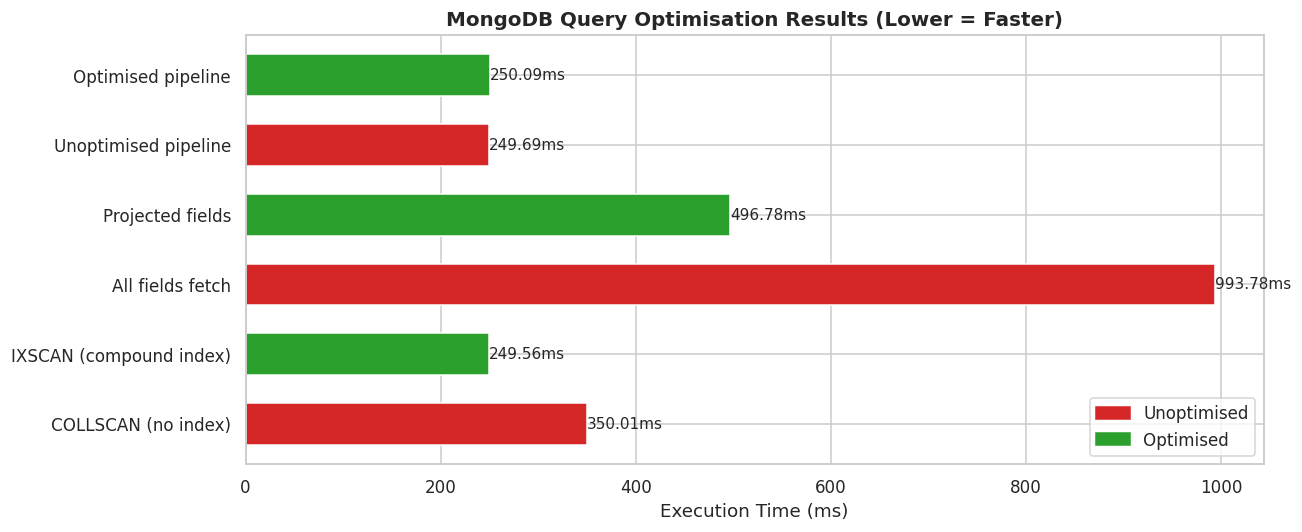

In [175]:
# STEP 7 - Optimisation summary bar chart
import matplotlib.pyplot as plt
import seaborn as sns

labels = [
    'COLLSCAN (no index)',
    'IXSCAN (compound index)',
    'All fields fetch',
    'Projected fields',
    'Unoptimised pipeline',
    'Optimised pipeline'
]
times_ms = [t_collscan, t_indexed, t_all, t_proj, t_unopt, t_opt]
bar_colors = ['#d62728','#2ca02c','#d62728','#2ca02c','#d62728','#2ca02c']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(labels, times_ms, color=bar_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, times_ms):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}ms', va='center', fontsize=10)
ax.set_title('MongoDB Query Optimisation Results (Lower = Faster)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Execution Time (ms)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#d62728',label='Unoptimised'),
                   Patch(color='#2ca02c',label='Optimised')], loc='lower right')
plt.tight_layout()
plt.show()